547 730 3
547 730


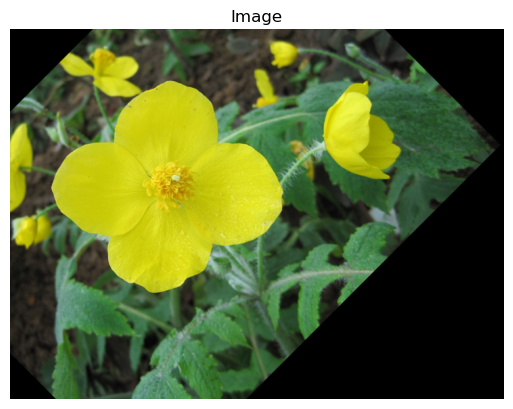

In [18]:
import cv2
import numpy as np
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
imgInfo = img.shape
height = imgInfo[0]
width = imgInfo[1]
print(height,width,imgInfo[2])
# 2*3 
matRotate = cv2.getRotationMatrix2D((height*0.5,width*0.5),45,1)# mat rotate 1 center 2 angle 3 scale
# matRotate = cv2.getRotationMatrix2D((width*0.5,height*0.5),45,1)# mat rotate 1 center 2 angle 3 scale
#100*100 25
# OpenCV 中坐标是 (x, y) 即 (列, 行)：
dst = cv2.warpAffine(img,matRotate,(width,height))
print(dst.shape[0],dst.shape[1])
import matplotlib.pyplot as plt
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Image')
plt.axis('off')
plt.show()


原图尺寸: 730 x 547
旋转后尺寸: 902 x 901


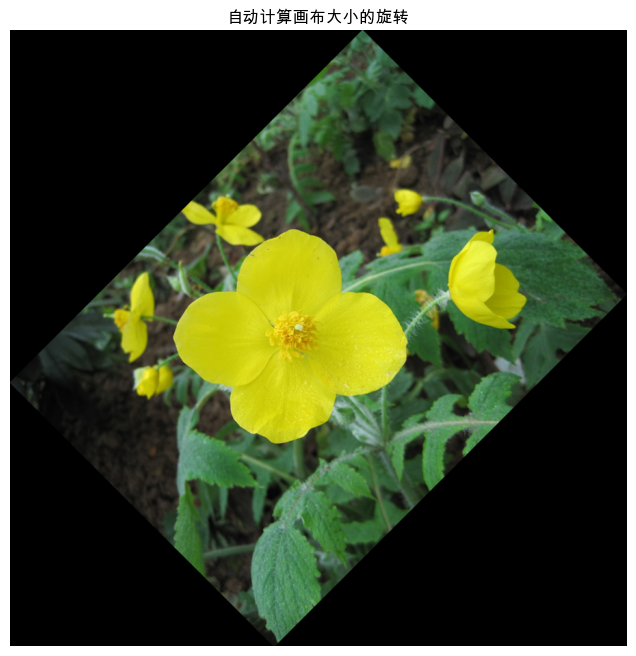

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

def rotate_image_auto_size(img, angle, scale=1.0):
    """
    旋转图像并自动计算合适的画布大小
    """
    height, width = img.shape[:2]
    center = (width/2, height/2)

    # 获取旋转矩阵
    matRotate = cv2.getRotationMatrix2D(center, angle, scale)

    # 计算旋转后的边界
    # 获取图像的四个角
    corners = np.array([
        [0, 0, 1],
        [width, 0, 1],
        [0, height, 1],
        [width, height, 1]
    ])

    # 变换四个角
    new_corners = np.dot(matRotate, corners.T).T

    # 计算新的边界
    x_min = int(np.min(new_corners[:, 0]))
    x_max = int(np.max(new_corners[:, 0]))
    y_min = int(np.min(new_corners[:, 1]))
    y_max = int(np.max(new_corners[:, 1]))

    # 计算平移量（将图像移到正区域）
    matRotate[0, 2] += -x_min
    matRotate[1, 2] += -y_min

    # 新尺寸
    new_width = x_max - x_min
    new_height = y_max - y_min

    # 应用变换
    dst = cv2.warpAffine(img, matRotate, (new_width, new_height))

    return dst, new_width, new_height

# 使用示例
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG')
dst, new_w, new_h = rotate_image_auto_size(img, 45, 1.0)

print(f"原图尺寸: {img.shape[1]} x {img.shape[0]}")
print(f"旋转后尺寸: {new_w} x {new_h}")

# 显示结果
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title('自动计算画布大小的旋转')
plt.axis('off')
plt.show()